In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import os

from sksurv.nonparametric import kaplan_meier_estimator

# for now I will just use the forest model from scikit-survival
from sksurv.ensemble import RandomSurvivalForest
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sksurv.datasets import load_gbsg2
from sksurv.ensemble import RandomSurvivalForest
from sksurv.preprocessing import OneHotEncoder
from sksurv.util import Surv


# Load Datasets

In [2]:
#load separate GEO datasets
gse21050 = GEOparse.get_GEO(geo="GSE21050", destdir="./data", silent=True)
gse30929 = GEOparse.get_GEO(geo="GSE30929", destdir="./data", silent=True)
gse71118 = GEOparse.get_GEO(geo="GSE71118", destdir="./data", silent=True)


NameError: name 'GEOparse' is not defined

In [8]:
# get all the metadata
metadata21050 = gse21050.phenotype_data
metadata30929 = gse30929.phenotype_data
metadata71118 = gse71118.phenotype_data


#print the columns of each metadata
#and save as csv for ease of access later
print("Metadata Columns:")
print("GSE21050:")
print(metadata21050.columns)
metadata21050.to_csv("./data/metadata21050.csv")

print("GSE30929:")
print(metadata30929.columns)
metadata30929.to_csv("./data/metadata30929.csv")

print("GSE71118:")
print(metadata71118.columns)
metadata71118.to_csv("./data/metadata71118.csv")

Metadata Columns:
GSE21050:
Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.cohort',
       'characteristics_ch1.1.tissue', 'characteristics_ch1.2.cinsarc group',
       'characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time',
       'characteristics_ch1.5.diagnosis', 'treatment_protocol_ch1',
       'molecule_ch1', 'extract_protocol_ch1', 'label_ch1',
       'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description',
       'data_processing', 'platform_id', 'contact_name', 'contact_email',
       'contact_laboratory', 'contact_department', 'contact_institute',
       'contact_address', 'contact_city', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count', 'characteristics_ch1.3.diagnosis'],
      dtype='object')
GSE30929:
Index(['title', 'geo_accession', '

In [9]:
#keep relevant columns for analysis
#this will be geo_accession, metastasis status, time, and cancer type/diagnosis
# in GSE30929, distant recurrence-free survival (DRFS) is used instead of metastasis
cols_keep_21050 = ['geo_accession','characteristics_ch1.5.diagnosis', 'characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time']
cols_keep_30929 = ['geo_accession', 'source_name_ch1', 'characteristics_ch1.4.drfs', 'characteristics_ch1.5.tt.drfs']
cols_keep_71118 = ['geo_accession', 'source_name_ch1', 'characteristics_ch1.0.metastasis', 'characteristics_ch1.1.time' ]

col_names = ['geo_accession','cancer_type','metastasis_status','time']
# combine all metadata into one dataframe
#this looks a little intense, but it's just renaming columns and concatenating dataframes
metadata = pd.concat([metadata21050[cols_keep_21050].rename(columns=dict(zip(cols_keep_21050, col_names))),
                    metadata30929[cols_keep_30929].rename(columns=dict(zip(cols_keep_30929, col_names))),
                    metadata71118[cols_keep_71118].rename(columns=dict(zip(cols_keep_71118, col_names)))], 
                    keys=['GSE21050','GSE30929','GSE71118']).reset_index(level=0).rename(columns={'level_0':'dataset'})
metadata.head()

,dataset,geo_accession,cancer_type,metastasis_status,time
GSM525806,GSE21050,GSM525806,Liposarcoma - dedifferentiated,no,9
GSM525807,GSE21050,GSM525807,Leiomyosarcoma,yes,1.22
GSM525808,GSE21050,GSM525808,Undifferentiated sarcoma,yes,0.92
GSM525809,GSE21050,GSM525809,Other,yes,1.48
GSM525810,GSE21050,GSM525810,Undifferentiated sarcoma,no,0.21


In [10]:
metadata.cancer_type.value_counts()

cancer_type
Undifferentiated sarcoma            225
Leiomyosarcoma                      173
Other                                73
Liposarcoma - dedifferentiated       62
liposarcoma, well-differentiated     52
Dedifferentiated liposarcoma         44
Myxofibrosarcoma                     43
liposarcoma, dedifferentiated        40
liposarcoma, pleomorphic             20
liposarcoma, myxoid                  17
liposarcoma, myxoid/round cell       11
Liposarcoma                           1
Name: count, dtype: int64

In [11]:
#remove missing data
metadata = metadata.dropna()
metadata.cancer_type.value_counts()

cancer_type
Undifferentiated sarcoma            225
Leiomyosarcoma                      173
Other                                73
Liposarcoma - dedifferentiated       62
liposarcoma, well-differentiated     52
Dedifferentiated liposarcoma         44
Myxofibrosarcoma                     43
liposarcoma, dedifferentiated        40
liposarcoma, pleomorphic             20
liposarcoma, myxoid                  17
liposarcoma, myxoid/round cell       11
Liposarcoma                           1
Name: count, dtype: int64

In [12]:
# keep only data with liposarcoma
sarcoma_list = ['Liposarcoma - dedifferentiated',
 'liposarcoma, dedifferentiated',
 'liposarcoma, myxoid/round cell',
 'liposarcoma, myxoid',
 'liposarcoma, pleomorphic',
 'liposarcoma, well-differentiated',
 'Dedifferentiated liposarcoma',
 'Liposarcoma']

metadata = metadata[metadata.cancer_type.isin(sarcoma_list)]

metadata.cancer_type.value_counts()

cancer_type
Liposarcoma - dedifferentiated      62
liposarcoma, well-differentiated    52
Dedifferentiated liposarcoma        44
liposarcoma, dedifferentiated       40
liposarcoma, pleomorphic            20
liposarcoma, myxoid                 17
liposarcoma, myxoid/round cell      11
Liposarcoma                          1
Name: count, dtype: int64

In thier study they use 192 samples, where as the full list is 247. Im wondering if during batch correction they removed 55?

In [47]:
#need to standardize metastasis status values
metadata.metastasis_status.value_counts()

metastasis_status
False    170
True      77
Name: count, dtype: int64

In [46]:
metastasis_map = {
    'FALSE': False,
    'TRUE': True,
    'no': False,
    'yes': True,
    'No': False,
    'yes': True,
    'Yes': True
    }
metadata['metastasis_status'] = metadata['metastasis_status'].map(metastasis_map)

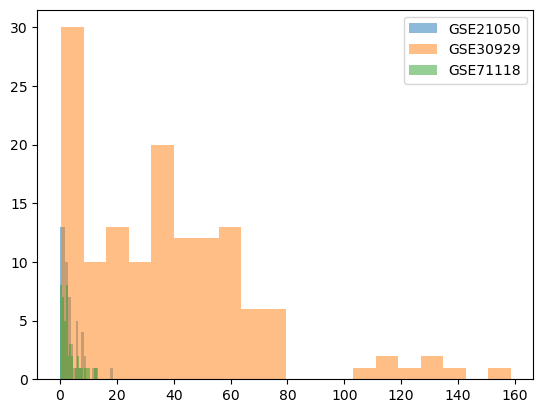

In [ ]:
#plot histograms of survival times for each dataset
for dataset in metadata['dataset'].unique():
    data_subset = metadata[metadata['dataset'] == dataset]
    plt.hist(data_subset['time'], bins=20, alpha=0.5, label=dataset)
plt.legend()
plt.show()

In [51]:
#convert GSE30950 time to years
metadata.loc[metadata['dataset']=='GSE30929', 'time'] = metadata.loc[metadata['dataset']=='GSE30929', 'time'] / 12

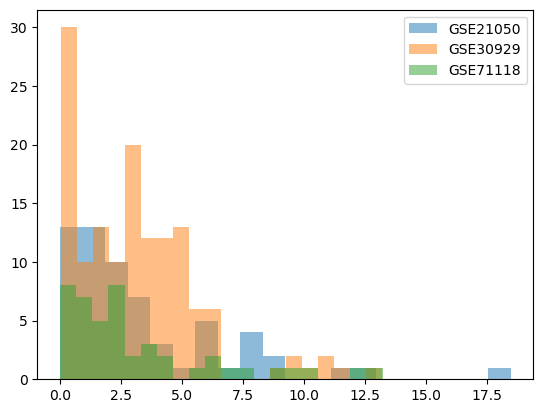

In [52]:
#plot histograms of survival times for each dataset
for dataset in metadata['dataset'].unique():
    data_subset = metadata[metadata['dataset'] == dataset]
    plt.hist(data_subset['time'], bins=20, alpha=0.5, label=dataset)
plt.legend()
plt.show()

In [53]:
#save combined metadata to csv
metadata.to_csv("./data/combined_metadata.csv", index=False)

# Combining data

In [ ]:
table21050 = gse21050.pivot_samples('VALUE')
table30929 = gse30929.pivot_samples('VALUE')
table71118 = gse71118.pivot_samples('VALUE')
#combine expression data
#GSE21050 is not log scaled
expression_data = pd.concat([np.log2(table21050+1), table30929, table71118], axis=1, join='inner')
expression_data.shape

(22215, 762)

<Axes: xlabel='name'>

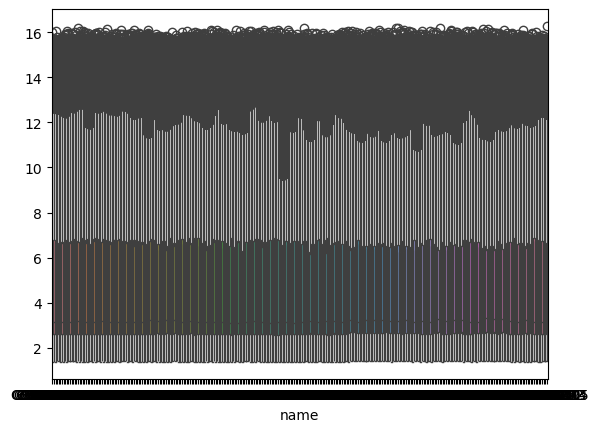

In [27]:
sns.boxplot(data=np.log2(table21050+1))

<Axes: xlabel='name'>

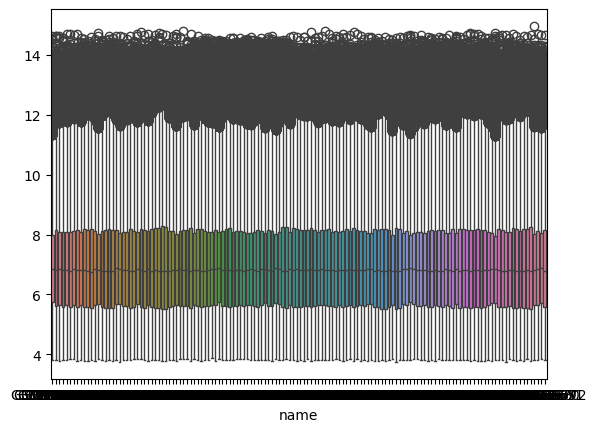

In [26]:
sns.boxplot(data=table30929)

In [8]:
# keep only liposarcoma samples in expression data
expression_data = expression_data[metadata['geo_accession']]
expression_data.shape

(22215, 247)

In [9]:
#save combined expression data to csv
expression_data.to_csv("./data/combined_expression_data_unscaled.csv", index=True)


In [47]:
#load expression data
expression_data = pd.read_csv("./data/combined_expression_data_unscaled.csv", index_col=0)
metadata = pd.read_csv("./data/combined_metadata.csv")

(22215, 248)

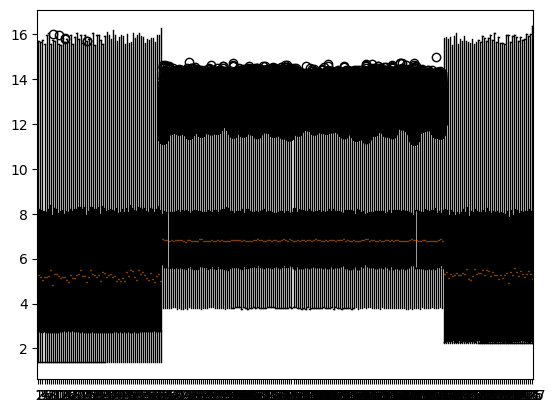

In [48]:
plot = plt.boxplot(expression_data)

In [49]:
metadata.head()
# Convert the 'color' column to a 'category' dtype
dataset_map = {
    'GSE21050': 0,
    'GSE30929': 1,
    'GSE71118': 2
}
batch = metadata['dataset'].map(dataset_map)


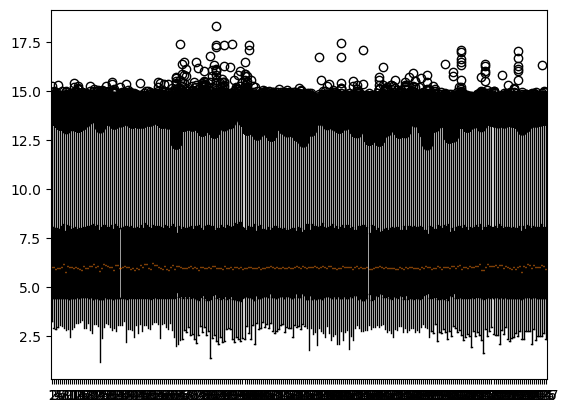

In [50]:
# normalize expression data
from inmoose.pycombat import pycombat_norm


# run pycombat_norm
df_corrected = pycombat_norm(expression_data, batch)

# visualize results
plt.boxplot(df_corrected)
plt.show()

In [52]:
#save scaled data
df_corrected.to_csv("./data/combined_expression_data_scaled.csv", index=True)

In [53]:
#load scaled data
df_corrected = pd.read_csv("./data/combined_expression_data_scaled.csv", index_col=0)

In [16]:
metadata.head()

,dataset,geo_accession,cancer_type,metastasis_status,time
0,GSE21050,GSM525806,Liposarcoma - dedifferentiated,False,9.00
1,GSE21050,GSM525811,Liposarcoma - dedifferentiated,True,0.95
2,GSE21050,GSM525812,Liposarcoma - dedifferentiated,True,0.87
3,GSE21050,GSM525814,Liposarcoma - dedifferentiated,False,2.84
4,GSE21050,GSM525818,Liposarcoma - dedifferentiated,False,4.04


Text(0.5, 0, 'time $t$')

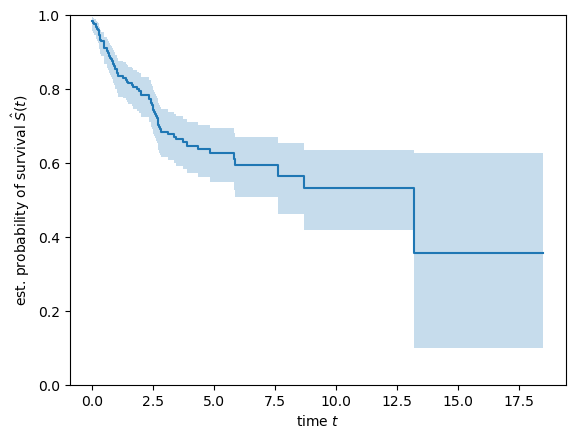

In [17]:
# make a simple survival analysis dataframe

time, survival_prob, conf_int = kaplan_meier_estimator(
    metadata['metastasis_status'], metadata['time'], conf_type="log-log"
)
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

# Univariate Cox analysis
The paper Asserts that is uses Maximal Information Coefficient (MIC) to do feature selection. I trie finding any information about this, but this seem very non-standard. I will instead be doing a univariate Cox survivail analyis, and keep features with p<= 0.05. 

I will use the Lifeline package, because survkit in python does not support p-values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
import pandas as pd

In [ ]:
metadata= pd.read_csv('data/combined_metadata.csv')
y= metadata[['geo_accession','metastasis_status','time']].set_index('geo_accession')
X = pd.read_csv('data/combined_expression_data_scaled.csv', index_col=0).convert_dtypes().transpose()

In [ ]:
def fit_and_score_features2(X):
   y=X[["event_observed","duration"]]
   X.drop(["duration", "event_observed"], axis=1, inplace=True)
   n_features = X.shape[1]
   scores = np.empty(n_features)
   m = CoxPHFitter()

   for j in range(n_features):
       Xj = X.iloc[:, j:j+1]
       Xj=pd.merge(Xj, y,  how='right', left_index=True, right_index=True)
       m.fit(Xj, duration_col="duration", event_col="event_observed", show_progress=True)
       scores[j] = m.score_
   return scores

def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = []
    # Fit a CoxPH model for each feature
    for j in range(n_features):
        Xj = X.iloc[:, j : j + 1] # Select one feature

        try:
            Xj = pd.merge(Xj, y, left_index=True, right_index=True)
            #Xj= Xj['1007_s_at'].drop_duplicates()
            m = CoxPHFitter()
            m.fit(Xj, 'time','metastasis_status' )
            scores.append(m.summary)
        except Exception as e:
            scores[j] = 0.0
    return scores

scores = fit_and_score_features(X, y)

In [ ]:
df=pd.concat(scores, ignore_index=True)

In [ ]:
df.index = X.columns
df.head()

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
ID_REF,,,,,,,,,,,
1007_s_at,0.052406,1.053804,0.169497,-0.279801,0.384614,0.755934,1.469047,0.0,0.309189,7.571780e-01,0.401296
1053_at,1.127196,3.086987,0.201514,0.732235,1.522156,2.079724,4.582094,0.0,5.593633,2.223668e-08,25.422483
117_at,0.120392,1.127939,0.092257,-0.060429,0.301213,0.941361,1.351498,0.0,1.304959,1.919067e-01,2.381523
121_at,-0.257783,0.772763,0.212171,-0.673630,0.158064,0.509854,1.171241,0.0,-1.214981,2.243733e-01,2.156027
1255_g_at,0.468415,1.597460,0.144028,0.186124,0.750706,1.204572,2.118494,0.0,3.252239,1.144996e-03,9.770441


In [ ]:
df.to_csv('lifeline_univ_cox_pvals.csv')

(array([4810., 1340.,  981.,  828.,  682.,  633.,  573.,  617.,  558.,
         468.,  502.,  484.,  446.,  462.,  415.,  445.,  397.,  360.,
         332.,  334.,  346.,  374.,  390.,  360.,  314.,  346.,  327.,
         334.,  312.,  321.,  295.,  331.,  284.,  332.,  311.,  325.,
         285.,  337.,  316.,  308.]),
 array([1.21296742e-10, 2.50000001e-02, 5.00000001e-02, 7.50000001e-02,
        1.00000000e-01, 1.25000000e-01, 1.50000000e-01, 1.75000000e-01,
        2.00000000e-01, 2.25000000e-01, 2.50000000e-01, 2.75000000e-01,
        3.00000000e-01, 3.25000000e-01, 3.50000000e-01, 3.75000000e-01,
        4.00000000e-01, 4.25000000e-01, 4.50000000e-01, 4.75000000e-01,
        5.00000000e-01, 5.25000000e-01, 5.50000000e-01, 5.75000000e-01,
        6.00000000e-01, 6.25000000e-01, 6.50000000e-01, 6.75000000e-01,
        7.00000000e-01, 7.25000000e-01, 7.50000000e-01, 7.75000000e-01,
        8.00000000e-01, 8.25000000e-01, 8.50000000e-01, 8.75000000e-01,
        9.00000000e-01, 9.2500

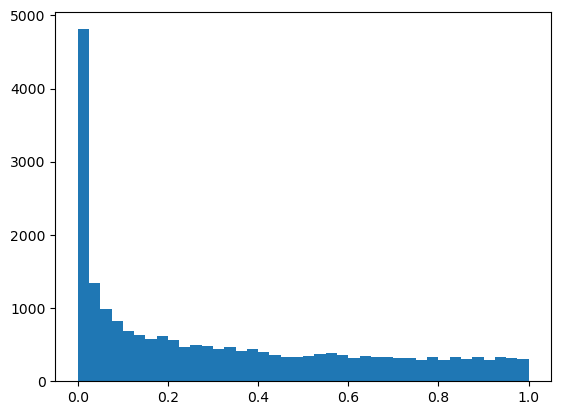

In [ ]:
plt.hist(df.p, bins=40)

In [ ]:
sig = df[df.p<=0.05].shape[0]
print("precent sig", sig / len(df))

precent sig 0.27683997299122215


In [ ]:
sig_ids = df[df.p<=0.05].index.to_list()
sig_expression = X.loc[:,sig_ids]
sig_expression.to_csv('./data/lifeline_univ_cox_sig_expression.csv')

# Model Pipeline

In [ ]:
features_keep =list(series_total.index)
X_sel = X[features_keep]
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.3, random_state=42)

In [ ]:
print("Fitting Random Survival Forest...")
rsf.fit(X_train, y_train)

# Evaluate model performance (C-index)
train_score = rsf.score(X_train, y_train)
test_score = rsf.score(X_test, y_test)
print(f"\nModel Performance (C-index):")
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")


#extract feature importances using permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(rsf, 
                                X_test, 
                                y_test, n_repeats=10, random_state=42, n_jobs=8)


Fitting Random Survival Forest...

Model Performance (C-index):
Training score: 0.9648
Testing score: 0.7553


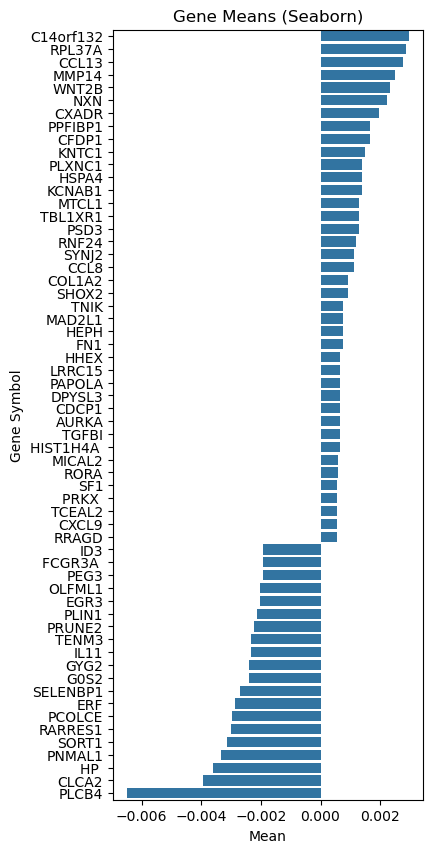

In [ ]:
result_df = pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns,
)
merge = pd.merge(result_df, gene_info, how='inner', left_index=True, right_on='ID')
merge = merge.groupby('Gene Symbol')[['importances_mean', 'importances_std']].mean()

df_sorted = merge.sort_values('importances_mean', ascending=False)

top40 = df_sorted.head(40)
bottom20 = df_sorted.tail(20)

#take top 40 and bottom 20
df_subset = pd.concat([top40, bottom20])

#and remove extra test from indes
df_subset.index = df_subset.index.str.split("///", n=1).str[0]

plt.figure(figsize=(4, 10))
sns.barplot(
    data=df_subset,
    x='importances_mean',
    y="Gene Symbol",
)

plt.xlabel("Mean")
plt.ylabel("Gene Symbol")
plt.title("Gene Means (Seaborn)")
#plt.tight_layout()
plt.show()

In [ ]:
df_sorted

,importances_mean,importances_std
Gene Symbol,,
C14orf132,0.002966,0.001158
RPL37A,0.002873,0.001131
CCL13,0.002780,0.001758
MMP14,0.002502,0.003822
WNT2B,0.002317,0.001390
...,...,...
SORT1,-0.003151,0.001324
PNMAL1,-0.003336,0.000741
HP /// HPR,-0.003614,0.003086
